# CP5 · Notebook 03 — El entorno highway-env

Explorar observación, acción, recompensa, rollout aleatorio. ~5 min.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import gymnasium as gym
import highway_env
from pathlib import Path
OUT = Path('../outputs'); OUT.mkdir(exist_ok=True)

def make_env(seed=0):
    env = gym.make('highway-v0', config={
        'observation': {'type': 'Kinematics', 'vehicles_count': 5,
                         'features': ['presence','x','y','vx','vy'], 'normalize': True},
        'action': {'type': 'DiscreteMetaAction'},
        'lanes_count': 4, 'vehicles_count': 20, 'duration': 40,
        'policy_frequency': 5, 'simulation_frequency': 15,
    })
    env.reset(seed=seed)
    return env

objc[17308]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib (0x11236cbf8) and /private/tmp/claude-501/-Users-erlantzmarcos-Projects-AIC/99882926-c5dd-4419-9d4b-4d9562471efd/scratchpad/venv-cp5/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11296c9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[17308]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib (0x11236cc48) and /private/tmp/claude-501/-Users-erlantzmarcos-Projects-AIC/99882926-c5dd-4419-9d4b-4d9562471efd/scratchpad/venv-cp5/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11296ca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[17308]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib 

## 1. Acciones disponibles

In [2]:
env = make_env(0)
print(f'Espacio de acciones: {env.action_space}')
print('Significado de cada acción:')
for action_id, name in {i: n for n, i in env.unwrapped.action_type.actions_indexes.items()}.items():
    print(f'  {action_id}: {name}')
env.close()

Espacio de acciones: Discrete(5)
Significado de cada acción:
  0: LANE_LEFT
  1: IDLE
  2: LANE_RIGHT
  3: FASTER
  4: SLOWER


## 2. Observación

5 vehículos × 5 features = matriz (5, 5).
- Fila 0: ego (presence=1, x=0, y=lane, vx, vy)
- Filas 1–4: 4 vecinos más cercanos (relativos al ego, normalizados)

In [3]:
env = make_env(0)
obs, _ = env.reset(seed=0)
print(f'Shape: {obs.shape}\n')
print(f'{"presence":>8s} {"x":>8s} {"y":>8s} {"vx":>8s} {"vy":>8s}')
for i, row in enumerate(obs):
    tag = 'ego' if i == 0 else f'v{i}'
    print(f'{tag:>3s}: {row[0]:>8.3f} {row[1]:>8.3f} {row[2]:>8.3f} {row[3]:>8.3f} {row[4]:>8.3f}')
env.close()

Shape: (5, 5)

presence        x        y       vx       vy
ego:    1.000    0.887    0.750    0.312    0.000
 v1:    1.000    0.091   -0.250   -0.048    0.000
 v2:    1.000    0.201   -0.250   -0.027    0.000
 v3:    1.000    0.317    0.000   -0.015    0.000
 v4:    1.000    0.422   -0.500   -0.049    0.000


## 3. Recompensa default

```
reward = collision * -1
       + right_lane * 0.1     (estar en el carril derecho da bonus pequeño)
       + high_speed * 0.4     (proporcional al speed normalizado [0, 1])
       + ...                  (otros factores: ver código de highway-env)
```
Veamos qué recompensa da el entorno en un rollout aleatorio.

In [4]:
env = make_env(0)
obs, _ = env.reset(seed=0)
rewards = []
for step in range(30):
    a = env.action_space.sample()
    obs, r, done, trunc, info = env.step(a)
    rewards.append((step, a, r, info.get('crashed', False), info.get('speed', 0)))
    if done or trunc: break
env.close()

print(f'{"step":>4s} {"act":>4s} {"reward":>8s} {"crashed":>9s} {"speed":>8s}')
for s, a, r, c, v in rewards[:15]:
    print(f'{s:>4d} {a:>4d} {r:>8.3f} {str(c):>9s} {v:>8.2f}')
print(f'\nTotal return: {sum(r for _,_,r,_,_ in rewards):.2f}')

step  act   reward   crashed    speed
   0    2    0.867     False    25.00
   1    1    0.867     False    25.00
   2    1    0.867     False    25.00
   3    3    0.906     False    26.49
   4    0    0.902     False    27.53
   5    3    0.921     False    28.27
   6    4    0.900     False    27.30
   7    3    0.924     False    28.10
   8    1    0.941     False    28.67
   9    4    0.913     False    27.57
  10    2    0.908     False    26.81
  11    0    0.878     False    26.27
  12    1    0.868     False    25.89
  13    0    0.823     False    25.63
  14    1    0.818     False    25.44

Total return: 26.53


## 4. Rollout aleatorio — 5 episodios completos

Ya tienes una idea de qué hace el entorno. Veamos cómo le va a un agente que elige acciones al azar.

In [5]:
n_episodes = 5
results = []
for ep in range(n_episodes):
    env = make_env(seed=ep)
    obs, _ = env.reset(seed=ep)
    ep_return, steps, crashed = 0.0, 0, False
    while True:
        a = env.action_space.sample()
        obs, r, done, trunc, info = env.step(a)
        ep_return += r
        steps += 1
        if done or trunc:
            crashed = info.get('crashed', False)
            break
    env.close()
    results.append((ep, ep_return, steps, crashed))
    print(f'  Ep {ep}: return={ep_return:.2f}  steps={steps}  crashed={crashed}')

rng_returns = [r for _, r, _, _ in results]
rng_crashes = [c for _, _, _, c in results]
print(f'\nRANDOM baseline (5 ep): return medio = {np.mean(rng_returns):.2f}  · % colisión = {100*sum(rng_crashes)/n_episodes:.0f}%')

  Ep 0: return=86.65  steps=102  crashed=True


  Ep 1: return=58.81  steps=77  crashed=True


  Ep 2: return=29.61  steps=37  crashed=True
  Ep 3: return=20.62  steps=23  crashed=True


  Ep 4: return=25.98  steps=32  crashed=True

RANDOM baseline (5 ep): return medio = 44.34  · % colisión = 100%


## 5. Render visual de 1 episodio

Activamos `render_mode='rgb_array'` y guardamos los frames como GIF.

✅ GIF guardado: ../outputs/03_random_rollout.gif  (20 frames)


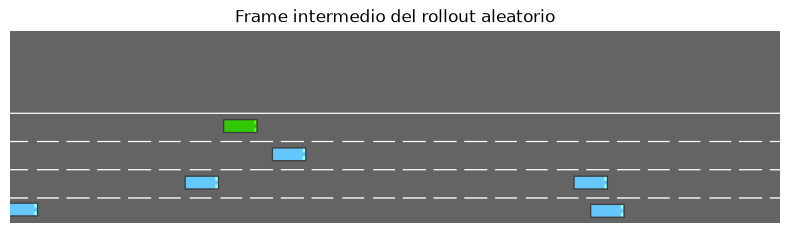

In [6]:
import imageio

env = gym.make('highway-v0', render_mode='rgb_array', config={
    'observation': {'type': 'Kinematics', 'vehicles_count': 5,
                     'features': ['presence','x','y','vx','vy'], 'normalize': True},
    'action': {'type': 'DiscreteMetaAction'},
    'lanes_count': 4, 'vehicles_count': 20, 'duration': 40,
})
obs, _ = env.reset(seed=42)
frames = []
for _ in range(40):
    frame = env.render()
    if frame is not None:
        frames.append(frame)
    a = env.action_space.sample()
    obs, r, done, trunc, info = env.step(a)
    if done or trunc: break
env.close()

if frames:
    imageio.mimsave(OUT / '03_random_rollout.gif', frames, duration=0.1)
    print(f'✅ GIF guardado: {OUT / "03_random_rollout.gif"}  ({len(frames)} frames)')
    plt.figure(figsize=(8, 4))
    plt.imshow(frames[len(frames)//2])
    plt.title('Frame intermedio del rollout aleatorio'); plt.axis('off')
    plt.tight_layout(); plt.show()
else:
    print('⚠️ no se generaron frames — verifica pygame instalado')

## 6. Cierre

Ya conoces el entorno. El return del agente aleatorio es bajo (probablemente <10) y choca con bastante frecuencia.

Ve a `04_baselines.ipynb` para añadir un baseline rule-based simple y tener referencias antes de entrenar el DQN.